# nlp-basics

## Use the description feature of the dataset and complete the following tasks:

In [1]:
import pandas as pd
import numpy as np 
import nltk
import spacy
pd.set_option("display.max_colwidth", None)

from nltk import FreqDist

In [2]:
df = pd.read_csv("winemag-data.csv")
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling (Lake Michigan Shore),Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child Block Pinot Noir (Willamette Valley),Pinot Noir,Sweet Cheeks


In [3]:
df = df[["description", "points"]]
df.head()

,description,points
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87
3,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",87
4,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.",87


# 1. Tokenize the description feature


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   description  129971 non-null  object
 1   points       129971 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.0+ MB


In [5]:
df.duplicated().sum()

np.int64(9993)

In [6]:
df[df.duplicated(keep=False)].sort_values(by="description")

,description,points
67614,"100% Malbec, it's redolent with dark plums, wild blueberries and peppery spices. The soft, silky flavors are light but have good concentration with the oak (80% American) seeming quite dialed back.",87
46540,"100% Malbec, it's redolent with dark plums, wild blueberries and peppery spices. The soft, silky flavors are light but have good concentration with the oak (80% American) seeming quite dialed back.",87
72181,"100% Sangiovese, this pale pink wine has notes of bubblegum, wild strawberry and spice. It drinks dry with medium-bodied flavors that linger on the finish.",88
119702,"100% Sangiovese, this pale pink wine has notes of bubblegum, wild strawberry and spice. It drinks dry with medium-bodied flavors that linger on the finish.",88
73731,"87-89 Barrel sample. A pleasurable, perfumed wine, with lovely fresh fruit and sweet flavors. It is relatively light, finishing freshly, with acidity and velvet tannins.",88
...,...,...
34154,"“Fresh and dry” is what the wine label advertises and is exactly what it delivers. It's a simple wine with tones of delicate kiwi, fresh fruit and some soapy floral aromas. In the mouth, it is compact and racy with a lean, spicy finish.",84
129801,"“Il Bugiardo,” which is Italian for “the liar,” is an honest and plump wine, with soft berry aromas that are woven into spicy notes of clove, black pepper, leather and tobacco. The finish is velvety and smooth.",88
87891,"“Il Bugiardo,” which is Italian for “the liar,” is an honest and plump wine, with soft berry aromas that are woven into spicy notes of clove, black pepper, leather and tobacco. The finish is velvety and smooth.",88
19401,"“Open and drink” the instructions should read, as this smooth and luscious wine is best enjoyed young. Half was barrel-fermented, yielding flavors of caramel, almond paste and buttered nuts. Pair with leek, bacon and potato soup, says the winery, which sounds just about perfect.",89


In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [8]:
df.head()

,description,points
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87
3,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",87
4,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.",87


In [9]:
df.isna().sum()

description    0
points         0
dtype: int64

In [10]:
df.loc[: , "char_count"] = df["description"].str.len().astype(int)
df.head()

,description,points,char_count
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87,186
3,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",87,199
4,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.",87,249


In [11]:
df.describe(include="number")

,points,char_count
count,119978.000000,119978.000000
mean,88.442164,242.810615
std,3.092835,67.143257
min,80.000000,20.000000
25%,86.000000,197.000000
50%,88.000000,237.000000
75%,91.000000,283.000000
max,100.000000,829.000000


In [12]:
df.describe(include="object")

,description
count,119978
unique,119955
top,"This zesty red has pretty aromas that suggest small red berry, blue flower and a whiff of moist soil. The vibrant palate offers sour cherry, pomegranate and a hint of anise alongside zesty acidity and refined tannins."
freq,2


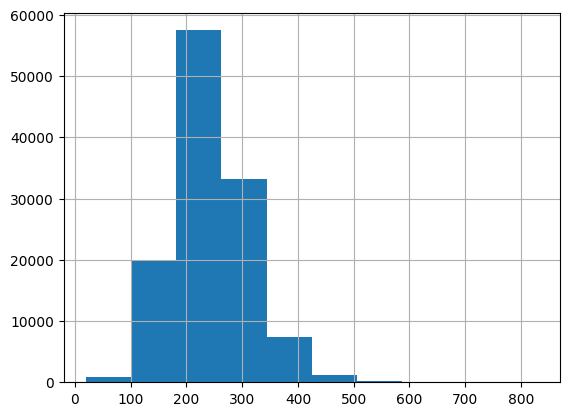

In [13]:
df["char_count"].hist();

<Axes: >

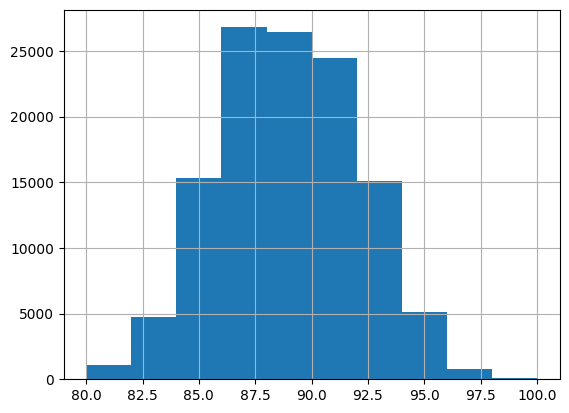

In [14]:
df["points"].hist()

In [15]:
# regex HTML pattern
pattern = 'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*|(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
df['no_html']= df['description'].str.replace(pattern, "", regex=True)
df.head()

,description,points,char_count,no_html
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity."
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016."
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87,186,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented."
3,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",87,199,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish."
4,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.",87,249,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew."


In [16]:
df["basic_tokens"] = df["no_html"].str.lower().str.split()
df.head()

,description,points,char_count,no_html,basic_tokens
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.","[aromas, include, tropical, fruit,, broom,, brimstone, and, dried, herb., the, palate, isn't, overly, expressive,, offering, unripened, apple,, citrus, and, dried, sage, alongside, brisk, acidity.]"
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.","[this, is, ripe, and, fruity,, a, wine, that, is, smooth, while, still, structured., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity., it's, already, drinkable,, although, it, will, certainly, be, better, from, 2016.]"
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87,186,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.","[tart, and, snappy,, the, flavors, of, lime, flesh, and, rind, dominate., some, green, pineapple, pokes, through,, with, crisp, acidity, underscoring, the, flavors., the, wine, was, all, stainless-steel, fermented.]"
3,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",87,199,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.","[pineapple, rind,, lemon, pith, and, orange, blossom, start, off, the, aromas., the, palate, is, a, bit, more, opulent,, with, notes, of, honey-drizzled, guava, and, mango, giving, way, to, a, slightly, astringent,, semidry, finish.]"
4,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.",87,249,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.","[much, like, the, regular, bottling, from, 2012,, this, comes, across, as, rather, rough, and, tannic,, with, rustic,, earthy,, herbal, characteristics., nonetheless,, if, you, think, of, it, as, a, pleasantly, unfussy, country, wine,, it's, a, good, companion, to, a, hearty, winter, stew.]"


In [17]:
df["nltk_tokens"] = df["no_html"].str.lower().apply(nltk.word_tokenize)
df.head()

,description,points,char_count,no_html,basic_tokens,nltk_tokens
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.","[aromas, include, tropical, fruit,, broom,, brimstone, and, dried, herb., the, palate, isn't, overly, expressive,, offering, unripened, apple,, citrus, and, dried, sage, alongside, brisk, acidity.]","[aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dried, herb, ., the, palate, is, n't, overly, expressive, ,, offering, unripened, apple, ,, citrus, and, dried, sage, alongside, brisk, acidity, .]"
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.","[this, is, ripe, and, fruity,, a, wine, that, is, smooth, while, still, structured., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity., it's, already, drinkable,, although, it, will, certainly, be, better, from, 2016.]","[this, is, ripe, and, fruity, ,, a, wine, that, is, smooth, while, still, structured, ., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity, ., it, 's, already, drinkable, ,, although, it, will, certainly, be, better, from, 2016, .]"
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87,186,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.","[tart, and, snappy,, the, flavors, of, lime, flesh, and, rind, dominate., some, green, pineapple, pokes, through,, with, crisp, acidity, underscoring, the, flavors., the, wine, was, all, stainless-steel, fermented.]","[tart, and, snappy, ,, the, flavors, of, lime, flesh, and, rind, dominate, ., some, green, pineapple, pokes, through, ,, with, crisp, acidity, underscoring, the, flavors, ., the, wine, was, all, stainless-steel, fermented, .]"
3,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",87,199,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.","[pineapple, rind,, lemon, pith, and, orange, blossom, start, off, the, aromas., the, palate, is, a, bit, more, opulent,, with, notes, of, honey-drizzled, guava, and, mango, giving, way, to, a, slightly, astringent,, semidry, finish.]","[pineapple, rind, ,, lemon, pith, and, orange, blossom, start, off, the, aromas, ., the, palate, is, a, bit, more, opulent, ,, with, notes, of, honey-drizzled, guava, and, mango, giving, way, to, a, slightly, astringent, ,, semidry, finish, .]"
4,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think of it as a pleasantly unfussy country wine, it's a good companion to a hearty winter stew.",87,249,"Much like the regular bottling from 2012, this comes across as rather rough and tannic, with rustic, earthy, herbal characteristics. Nonetheless, if you think

# 2. Remove stop words

In [18]:
from string import punctuation
from nltk.corpus import stopwords
nltk.download("stopwords")


stopwords = stopwords.words("english")
punc = [p for p in punctuation]
stopwords = stopwords + punc
stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bharat/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [19]:
df["no_stop"] = df["nltk_tokens"].apply(
    lambda text: [word for word in text if word not in stopwords]
)
df.head()

,description,points,char_count,no_html,basic_tokens,nltk_tokens,no_stop
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.","[aromas, include, tropical, fruit,, broom,, brimstone, and, dried, herb., the, palate, isn't, overly, expressive,, offering, unripened, apple,, citrus, and, dried, sage, alongside, brisk, acidity.]","[aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dried, herb, ., the, palate, is, n't, overly, expressive, ,, offering, unripened, apple, ,, citrus, and, dried, sage, alongside, brisk, acidity, .]","[aromas, include, tropical, fruit, broom, brimstone, dried, herb, palate, n't, overly, expressive, offering, unripened, apple, citrus, dried, sage, alongside, brisk, acidity]"
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.","[this, is, ripe, and, fruity,, a, wine, that, is, smooth, while, still, structured., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity., it's, already, drinkable,, although, it, will, certainly, be, better, from, 2016.]","[this, is, ripe, and, fruity, ,, a, wine, that, is, smooth, while, still, structured, ., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity, ., it, 's, already, drinkable, ,, although, it, will, certainly, be, better, from, 2016, .]","[ripe, fruity, wine, smooth, still, structured, firm, tannins, filled, juicy, red, berry, fruits, freshened, acidity, 's, already, drinkable, although, certainly, better, 2016]"
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87,186,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.","[tart, and, snappy,, the, flavors, of, lime, flesh, and, rind, dominate., some, green, pineapple, pokes, through,, with, crisp, acidity, underscoring, the, flavors., the, wine, was, all, stainless-steel, fermented.]","[tart, and, snappy, ,, the, flavors, of, lime, flesh, and, rind, dominate, ., some, green, pineapple, pokes, through, ,, with, crisp, acidity, underscoring, the, flavors, ., the, wine, was, all, stainless-steel, fermented, .]","[tart, snappy, flavors, lime, flesh, rind, dominate, green, pineapple, pokes, crisp, acidity, underscoring, flavors, wine, stainless-steel, fermented]"
3,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.",87,199,"Pineapple rind, lemon pith and orange blossom start off the aromas. The palate is a bit more opulent, with notes of honey-drizzled guava and mango giving way to a slightly astringent, semidry finish.","[pineapple, rind,, lemon, pith, and, orange, blossom, start, off, the, aromas., the, palate, is, a, bit, more, opulent,, with, notes, of, honey-drizzled, guava, and, mango, giving, way, to, a, slightly, astringent,, semidry, finish.]","[pineapple, rind, ,, lemon, pith, and, orange, blossom, start, off, the, aromas, ., the, palate, is, a, bit, more, opulent, ,, with, notes, of, hone

# 3. Stem the tokens

In [20]:
from nltk import PorterStemmer

stemmer = PorterStemmer()

df["stemmed"] = df["nltk_tokens"].apply(
    lambda text: [stemmer.stem(word) for word in text]
)

df.tail()

,description,points,char_count,no_html,basic_tokens,nltk_tokens,no_stop,stemmed
129966,"Notes of honeysuckle and cantaloupe sweeten this deliciously feather-light spätlese. It's intensely juicy, quenching the palate with streams of tart tangerine and grapefruit acidity, yet wraps up with a kiss of honey and peach.",90,227,"Notes of honeysuckle and cantaloupe sweeten this deliciously feather-light spätlese. It's intensely juicy, quenching the palate with streams of tart tangerine and grapefruit acidity, yet wraps up with a kiss of honey and peach.","[notes, of, honeysuckle, and, cantaloupe, sweeten, this, deliciously, feather-light, spätlese., it's, intensely, juicy,, quenching, the, palate, with, streams, of, tart, tangerine, and, grapefruit, acidity,, yet, wraps, up, with, a, kiss, of, honey, and, peach.]","[notes, of, honeysuckle, and, cantaloupe, sweeten, this, deliciously, feather-light, spätlese, ., it, 's, intensely, juicy, ,, quenching, the, palate, with, streams, of, tart, tangerine, and, grapefruit, acidity, ,, yet, wraps, up, with, a, kiss, of, honey, and, peach, .]","[notes, honeysuckle, cantaloupe, sweeten, deliciously, feather-light, spätlese, 's, intensely, juicy, quenching, palate, streams, tart, tangerine, grapefruit, acidity, yet, wraps, kiss, honey, peach]","[note, of, honeysuckl, and, cantaloup, sweeten, thi, delici, feather-light, spätlese, ., it, 's, intens, juici, ,, quench, the, palat, with, stream, of, tart, tangerin, and, grapefruit, acid, ,, yet, wrap, up, with, a, kiss, of, honey, and, peach, .]"
129967,"Citation is given as much as a decade of bottle age prior to release, which means it is pre-cellared and drinking at its peak. Baked cherry, cocoa and coconut flavors combine gracefully, with soft, secondary fruit compote highlights.",90,233,"Citation is given as much as a decade of bottle age prior to release, which means it is pre-cellared and drinking at its peak. Baked cherry, cocoa and coconut flavors combine gracefully, with soft, secondary fruit compote highlights.","[citation, is, given, as, much, as, a, decade, of, bottle, age, prior, to, release,, which, means, it, is, pre-cellared, and, drinking, at, its, peak., baked, cherry,, cocoa, and, coconut, flavors, combine, gracefully,, with, soft,, secondary, fruit, compote, highlights.]","[citation, is, given, as, much, as, a, decade, of, bottle, age, prior, to, release, ,, which, means, it, is, pre-cellared, and, drinking, at, its, peak, ., baked, cherry, ,, cocoa, and, coconut, flavors, combine, gracefully, ,, with, soft, ,, secondary, fruit, compote, highlights, .]","[citation, given, much, decade, bottle, age, prior, release, means, pre-cellared, drinking, peak, baked, cherry, cocoa, coconut, flavors, combine, gracefully, soft, secondary, fruit, compote, highlights]","[citat, is, given, as, much, as, a, decad, of, bottl, age, prior, to, releas, ,, which, mean, it, is, pre-cellar, and, drink, at, it, peak, ., bake, cherri, ,, cocoa, and, coconut, flavor, combin, grace, ,, with, soft, ,, secondari, fruit, compot, highlight, .]"
129968,"Well-drained gravel soil gives this wine its crisp and dry character. It is ripe and fruity, although the spice is subdued in favor of a more serious structure. This is a wine to age for a couple of years, so drink from 2017.",90,225,"Well-drained gravel soil gives this wine its crisp and dry character. It is ripe and fruity, although the spice is subdued in favor of a more serious structure. This is a wine to age for a couple of years, so drink from 2017.","[well-drained, gravel, soil, gives, this, wine, its, crisp, and, dry, character., it, is, ripe, and, fruity,, although, the, spice, is, subdued, in, favor, of, a, more, serious, structure., this, is, a, wine, to, age, for, a, couple, of, years,, so, drink, from, 2017.]","[well-drained, gravel, soil, gives, this, wine, its, crisp, and, dry, character, ., it, is, ripe, and, fruity, ,, although, the, spice, is, subdued, in, favor, of, a, more, serious, structur

# 4. Lemmatize the tokens

In [21]:
import spacy
# from thinc.api import enable_tensorflow
# enable_tensorflow()
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [22]:
# df["fast_lemmatization"] = ""

# nlp = spacy.load("en_core_web_sm")
# for i in range(len(df["description"])):
#     text = df["description"].iloc[0]
#     for doc in nlp.pipe(text, disable=["ner", "parser"], n_process=-1):
#         df["fast_lemmatization"].iloc[i] = [token.lemma_ for token in doc]

In [23]:
def lemmatize_process(text):
    doc = nlp(text)
    processed_doc = [token.lemma_ for token in doc]
    return processed_doc

In [24]:
df["lemmatized"] = df["description"].apply(lemmatize_process)

# df["lemmatized"] = df["description"].apply(lambda text: [token.lemma_ for token in text])

df.head()

,description,points,char_count,no_html,basic_tokens,nltk_tokens,no_stop,stemmed,lemmatized
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.","[aromas, include, tropical, fruit,, broom,, brimstone, and, dried, herb., the, palate, isn't, overly, expressive,, offering, unripened, apple,, citrus, and, dried, sage, alongside, brisk, acidity.]","[aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dried, herb, ., the, palate, is, n't, overly, expressive, ,, offering, unripened, apple, ,, citrus, and, dried, sage, alongside, brisk, acidity, .]","[aromas, include, tropical, fruit, broom, brimstone, dried, herb, palate, n't, overly, expressive, offering, unripened, apple, citrus, dried, sage, alongside, brisk, acidity]","[aroma, includ, tropic, fruit, ,, broom, ,, brimston, and, dri, herb, ., the, palat, is, n't, overli, express, ,, offer, unripen, appl, ,, citru, and, dri, sage, alongsid, brisk, acid, .]","[Aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dry, herb, ., the, palate, be, not, overly, expressive, ,, offer, unripene, apple, ,, citrus, and, dry, sage, alongside, brisk, acidity, .]"
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.","[this, is, ripe, and, fruity,, a, wine, that, is, smooth, while, still, structured., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity., it's, already, drinkable,, although, it, will, certainly, be, better, from, 2016.]","[this, is, ripe, and, fruity, ,, a, wine, that, is, smooth, while, still, structured, ., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity, ., it, 's, already, drinkable, ,, although, it, will, certainly, be, better, from, 2016, .]","[ripe, fruity, wine, smooth, still, structured, firm, tannins, filled, juicy, red, berry, fruits, freshened, acidity, 's, already, drinkable, although, certainly, better, 2016]","[thi, is, ripe, and, fruiti, ,, a, wine, that, is, smooth, while, still, structur, ., firm, tannin, are, fill, out, with, juici, red, berri, fruit, and, freshen, with, acid, ., it, 's, alreadi, drinkabl, ,, although, it, will, certainli, be, better, from, 2016, .]","[this, be, ripe, and, fruity, ,, a, wine, that, be, smooth, while, still, structure, ., firm, tannin, be, fill, out, with, juicy, red, berry, fruit, and, freshen, with, acidity, ., it, be, , already, drinkable, ,, although, it, will, certainly, be, well, from, 2016, .]"
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.",87,186,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity underscoring the flavors. The wine was all stainless-steel fermented.","[tart, and, snappy,, the, flavors, of, lime, flesh, and, rind, dominate., some, green, pineapple, pokes, through,, with, crisp, acidity, underscoring, the, flavors., the, wine, was, all, stainless-steel, fermented.]","[tart, and, snappy, ,, the, flavors, of, lime, flesh, and, rind, dominate, ., some, green, pineapple, pokes, through, ,, with, crisp, acidity, underscoring, the, flavors, ., the, wine, was, all, stainless-steel, fermented, .

In [ ]:
# test_df = df.head().copy()
# test_df["description"].apply(nlp).apply(list)
# nlp(test_df["description"])
# lemmatizer = nlp.get_pipe("lemmatizer")
# test_df["description"].apply(nlp.make_doc).apply(list).apply(lambda x: x.lemma_ for x in list)
# test_df["description"].apply(nlp)

# lemmatizer.lemmatize("j")

# doc = nlp(df["description"][4])
# doc[0:len(doc)-1].lemma_
# - docs = [nlp(text) for text in texts]
# + docs = list(nlp.pipe(texts))

# nlp("Give it back! He pleaded.")[
#     0 : len("Give it back! He pleaded.") - 1
# ].lemma_.split()
# df["lemmatized2"] = df["description"].apply(lambda doc: nlp(doc)[0 : len(doc)].lemma_)

# df.head()

# from spacy.tokens.doc import Doc import to_bytes
# df["lemmatized2"] = df["description"].apply(nlp.make_doc).apply(list)

# df.head()

# doc = df["lemmatized2"][4]
# # print(token for token in doc)
# token = doc[6]

# 5. Create two new features: "Cleaned_Stem_Description" and "Cleaned_Lemma_Description"

In [38]:
def cleaning_process(text):
    doc = nlp(text)
    processed_doc = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and not token.is_quote
        and not token.is_bracket
        and not token.is_currency
        and not token.like_url
        and not token.like_email
    ]
    return processed_doc

In [40]:
df["Cleaned_Stem_Description"] = df["stemmed"].apply(lambda x: " ".join(map(str, x)))
df["Cleaned_Stem_Description"] = df["Cleaned_Stem_Description"].apply(cleaning_process)
df.head()

,description,points,char_count,no_html,basic_tokens,nltk_tokens,no_stop,stemmed,lemmatized,stem2,Cleaned_Stem_Description
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.","[aromas, include, tropical, fruit,, broom,, brimstone, and, dried, herb., the, palate, isn't, overly, expressive,, offering, unripened, apple,, citrus, and, dried, sage, alongside, brisk, acidity.]","[aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dried, herb, ., the, palate, is, n't, overly, expressive, ,, offering, unripened, apple, ,, citrus, and, dried, sage, alongside, brisk, acidity, .]","[aromas, include, tropical, fruit, broom, brimstone, dried, herb, palate, n't, overly, expressive, offering, unripened, apple, citrus, dried, sage, alongside, brisk, acidity]","[aroma, includ, tropic, fruit, ,, broom, ,, brimston, and, dri, herb, ., the, palat, is, n't, overli, express, ,, offer, unripen, appl, ,, citru, and, dri, sage, alongsid, brisk, acid, .]","[Aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dry, herb, ., the, palate, be, not, overly, expressive, ,, offer, unripene, apple, ,, citrus, and, dry, sage, alongside, brisk, acidity, .]","aroma includ tropic fruit , broom , brimston and dri herb . the palat is n't overli express , offer unripen appl , citru and dri sage alongsid brisk acid .","[aroma, includ, tropic, fruit, broom, brimston, dri, herb, palat, overli, express, offer, unripen, appl, citru, dri, sage, alongsid, brisk, acid]"
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.","[this, is, ripe, and, fruity,, a, wine, that, is, smooth, while, still, structured., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity., it's, already, drinkable,, although, it, will, certainly, be, better, from, 2016.]","[this, is, ripe, and, fruity, ,, a, wine, that, is, smooth, while, still, structured, ., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity, ., it, 's, already, drinkable, ,, although, it, will, certainly, be, better, from, 2016, .]","[ripe, fruity, wine, smooth, still, structured, firm, tannins, filled, juicy, red, berry, fruits, freshened, acidity, 's, already, drinkable, although, certainly, better, 2016]","[thi, is, ripe, and, fruiti, ,, a, wine, that, is, smooth, while, still, structur, ., firm, tannin, are, fill, out, with, juici, red, berri, fruit, and, freshen, with, acid, ., it, 's, alreadi, drinkabl, ,, although, it, will, certainli, be, better, from, 2016, .]","[this, be, ripe, and, fruity, ,, a, wine, that, be, smooth, while, still, structure, ., firm, tannin, be, fill, out, with, juicy, red, berry, fruit, and, freshen, with, acidity, ., it, be, , already, drinkable, ,, although, it, will, certainly, be, well, from, 2016, .]","thi is ripe and fruiti , a wine that is smooth while still structur . firm tannin are fill out with juici red berri fruit and freshen with acid . it 's alreadi drinkabl , although it will certainli be better from 2016 .","[thi, ripe, fruiti, wine, smooth, structur, firm, tannin, fill, juici, red, berri, fruit, freshen, acid, alreadi, drinkabl, certainli, well, 2016]"
2,"Tart and snappy, the flavors of lime flesh and rind dominate. Some green pineapple pokes through, with crisp acidity un

In [41]:
df["Cleaned_Lemma_Description"] = df["lemmatized"].apply(lambda x: " ".join(map(str, x)))
df["Cleaned_Lemma_Description"] = df["Cleaned_Lemma_Description"].apply(cleaning_process)
df.head()

,description,points,char_count,no_html,basic_tokens,nltk_tokens,no_stop,stemmed,lemmatized,stem2,Cleaned_Stem_Description,Cleaned_Lemma_Description
0,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.",87,172,"Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.","[aromas, include, tropical, fruit,, broom,, brimstone, and, dried, herb., the, palate, isn't, overly, expressive,, offering, unripened, apple,, citrus, and, dried, sage, alongside, brisk, acidity.]","[aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dried, herb, ., the, palate, is, n't, overly, expressive, ,, offering, unripened, apple, ,, citrus, and, dried, sage, alongside, brisk, acidity, .]","[aromas, include, tropical, fruit, broom, brimstone, dried, herb, palate, n't, overly, expressive, offering, unripened, apple, citrus, dried, sage, alongside, brisk, acidity]","[aroma, includ, tropic, fruit, ,, broom, ,, brimston, and, dri, herb, ., the, palat, is, n't, overli, express, ,, offer, unripen, appl, ,, citru, and, dri, sage, alongsid, brisk, acid, .]","[Aromas, include, tropical, fruit, ,, broom, ,, brimstone, and, dry, herb, ., the, palate, be, not, overly, expressive, ,, offer, unripene, apple, ,, citrus, and, dry, sage, alongside, brisk, acidity, .]","aroma includ tropic fruit , broom , brimston and dri herb . the palat is n't overli express , offer unripen appl , citru and dri sage alongsid brisk acid .","[aroma, includ, tropic, fruit, broom, brimston, dri, herb, palat, overli, express, offer, unripen, appl, citru, dri, sage, alongsid, brisk, acid]","[aromas, include, tropical, fruit, broom, brimstone, dry, herb, palate, overly, expressive, offer, unripene, apple, citrus, dry, sage, alongside, brisk, acidity]"
1,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.",87,227,"This is ripe and fruity, a wine that is smooth while still structured. Firm tannins are filled out with juicy red berry fruits and freshened with acidity. It's already drinkable, although it will certainly be better from 2016.","[this, is, ripe, and, fruity,, a, wine, that, is, smooth, while, still, structured., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity., it's, already, drinkable,, although, it, will, certainly, be, better, from, 2016.]","[this, is, ripe, and, fruity, ,, a, wine, that, is, smooth, while, still, structured, ., firm, tannins, are, filled, out, with, juicy, red, berry, fruits, and, freshened, with, acidity, ., it, 's, already, drinkable, ,, although, it, will, certainly, be, better, from, 2016, .]","[ripe, fruity, wine, smooth, still, structured, firm, tannins, filled, juicy, red, berry, fruits, freshened, acidity, 's, already, drinkable, although, certainly, better, 2016]","[thi, is, ripe, and, fruiti, ,, a, wine, that, is, smooth, while, still, structur, ., firm, tannin, are, fill, out, with, juici, red, berri, fruit, and, freshen, with, acid, ., it, 's, alreadi, drinkabl, ,, although, it, will, certainli, be, better, from, 2016, .]","[this, be, ripe, and, fruity, ,, a, wine, that, be, smooth, while, still, structure, ., firm, tannin, be, fill, out, with, juicy, red, berry, fruit, and, freshen, with, acidity, ., it, be, , already, drinkable, ,, although, it, will, certainly, be, well, from, 2016, .]","thi is ripe and fruiti , a wine that is smooth while still structur . firm tannin are fill out with juici red berri fruit and freshen with acid . it 's alreadi drinkabl , although it will certainli be better from 2016 .","[thi, ripe, fruiti, wine, smooth, structur, firm, tannin, fill, juici, red, berr

# 6. Build a word cloud based on Cleaned_Lemma_Description

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

lemma_only = df["Cleaned_Lemma_Description"].explode().astype(str).to_list()
lemma_only = " ".join(lemma_only)
lemma_cloud = WordCloud(min_word_length=2).generate(lemma_only)

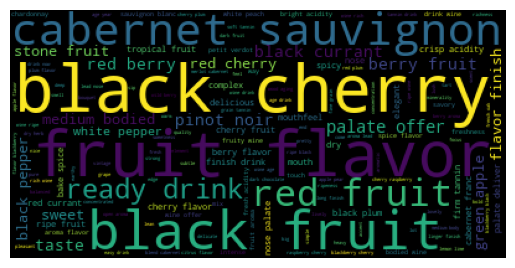

<Figure size 640x480 with 0 Axes>

In [44]:
plt.imshow(lemma_cloud)
plt.grid(visible=False)
plt.axis("off")
plt.show()
plt.tight_layout();

In [ ]:
df.to_csv("wine_to_water.csv", index=False)